# EDA & Leakage Audit

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
os.chdir("../../")
os.getcwd()

'c:\\Users\\Ansh Lulla\\VS-Code\\PlantDiseaseProject\\plant-disease-project'

## Config

In [6]:
DATASET_ROOT = Path('Dataset')  # Change path if needed
SEED = 42

## Load Dataset Structure

In [7]:
class_folders = sorted([d for d in DATASET_ROOT.iterdir() if d.is_dir()])
class_names = [d.name for d in class_folders]
num_classes = len(class_names)

print(f"Total classes: {num_classes}")
print(f"Class names:\n{class_names}")

Total classes: 23
Class names:
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite']


## Count Images per Class

In [8]:
class_counts = {}
for class_dir in class_folders:
    images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png')) + list(class_dir.glob('*.jpeg'))
    class_counts[class_dir.name] = len(images)

class_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))
total_images = sum(class_counts.values())

print(f"\nTotal images: {total_images}")
print(f"\nClass distribution:")
for cls, count in class_counts.items():
    pct = (count / total_images) * 100
    print(f"{cls}: {count} ({pct:.1f}%)")


Total images: 35414

Class distribution:
Tomato__Tomato_YellowLeaf__Curl_Virus: 3208 (9.1%)
Tomato_Bacterial_spot: 2127 (6.0%)
Apple___Apple_scab: 2016 (5.7%)
Apple___healthy: 2008 (5.7%)
Apple___Black_rot: 1987 (5.6%)
Tomato_Late_blight: 1909 (5.4%)
Corn_(maize)___Northern_Leaf_Blight: 1908 (5.4%)
Corn_(maize)___Common_rust_: 1907 (5.4%)
Corn_(maize)___healthy: 1859 (5.2%)
Tomato_Septoria_leaf_spot: 1771 (5.0%)
Apple___Cedar_apple_rust: 1760 (5.0%)
Tomato_Spider_mites_Two_spotted_spider_mite: 1676 (4.7%)
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1642 (4.6%)
Pepper__bell___healthy: 1478 (4.2%)
Tomato__Target_Spot: 1404 (4.0%)
Tomato_healthy: 1280 (3.6%)
Potato___Early_blight: 1000 (2.8%)
Potato___Late_blight: 1000 (2.8%)
Tomato_Early_blight: 1000 (2.8%)
Pepper__bell___Bacterial_spot: 997 (2.8%)
Tomato_Leaf_Mold: 952 (2.7%)
Tomato__Tomato_mosaic_virus: 373 (1.1%)
Potato___healthy: 152 (0.4%)


## Visualize Class Distribution

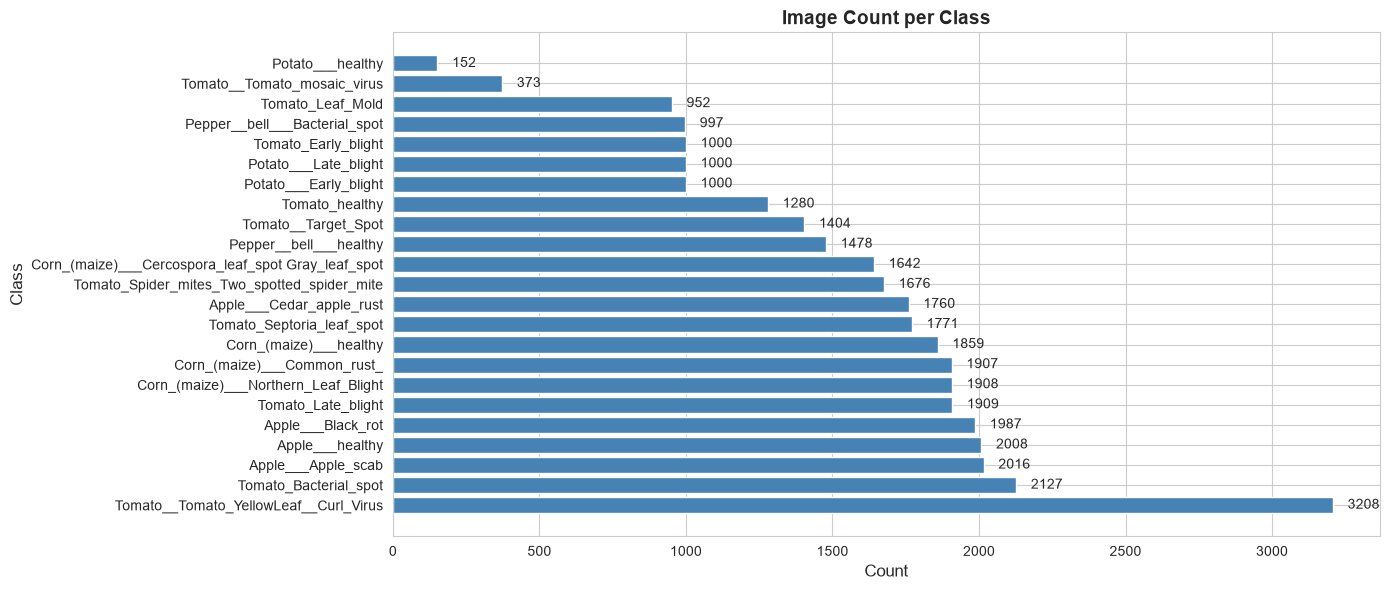


Imbalance ratio (max/min): 21.11x


In [9]:
df_counts = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(df_counts['Class'], df_counts['Count'], color='steelblue')
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Class', fontsize=12)
ax.set_title('Image Count per Class', fontsize=14, fontweight='bold')

for i, (idx, row) in enumerate(df_counts.iterrows()):
    ax.text(row['Count'] + 50, i, str(row['Count']), va='center')

plt.tight_layout()
plt.show()

print(f"\nImbalance ratio (max/min): {max(class_counts.values()) / min(class_counts.values()):.2f}x")

## Leakage Audit: Check Filename Patterns

In [10]:
all_images = []
for class_dir in class_folders:
    images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png')) + list(class_dir.glob('*.jpeg'))
    for img_path in images:
        all_images.append((class_dir.name, img_path.name, img_path))

sample_filenames = [img[1] for img in all_images[:10]]
print("Sample filenames:")
for fname in sample_filenames:
    print(f"  {fname}")

print(f"\nTotal files: {len(all_images)}")

Sample filenames:
  00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG
  01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG
  01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003_270deg.JPG
  01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003_90deg.JPG
  01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003_new30degFlipLR.JPG
  01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Scab 3112.JPG
  01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Scab 3112_90deg.JPG
  01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Scab 3112_new30degFlipLR.JPG
  0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Scab 3037.JPG
  0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Scab 3037_270deg.JPG

Total files: 35725


## Detect Augmented Images

In [11]:
augmentation_keywords = ['augmented', '_aug', 'brightness', 'rotation', 'flip', 'zoom', 'blur', 'noise', 'transform']

augmented_images = []
for class_name, fname, path in all_images:
    if any(keyword in fname.lower() for keyword in augmentation_keywords):
        augmented_images.append((class_name, fname))

print(f"Detected augmented images: {len(augmented_images)} / {len(all_images)}")
if augmented_images:
    print("\nAugmentation pattern detected!")
    print("Sample augmented filenames:")
    for cls, fname in augmented_images[:5]:
        print(f"  {cls}: {fname}")
    

Detected augmented images: 5001 / 35725

Augmentation pattern detected!
Sample augmented filenames:
  Apple___Apple_scab: 01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003_new30degFlipLR.JPG
  Apple___Apple_scab: 01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Scab 3112_new30degFlipLR.JPG
  Apple___Apple_scab: 0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Scab 3037_new30degFlipLR.JPG
  Apple___Apple_scab: 023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Scab 3487_new30degFlipLR.JPG
  Apple___Apple_scab: 029424b0-0ef5-491b-9ef5-069190d24d8f___FREC_Scab 3504_new30degFlipLR.JPG


## Extract Original Image IDs (if augmented)

In [12]:
if augmented_images:
    original_ids = defaultdict(list)
    for class_name, fname, path in all_images:
        base_name = fname.split('_')[0] if '_' in fname else fname.split('.')[0]
        original_ids[base_name].append((class_name, fname))
    
    print(f"Unique original image IDs: {len(original_ids)}")
    print("\nSample originals with augmentations:")
    for base_id, variants in list(original_ids.items())[:3]:
        print(f"  ID {base_id}: {len(variants)} variants")
        for cls, fname in variants[:2]:
            print(f"    - {fname}")
else:
    print("No augmentation detected. Dataset appears to be raw images only.")

Unique original image IDs: 26171

Sample originals with augmentations:
  ID 00075aa8-d81a-4184-8541-b692b78d398a: 1 variants
    - 00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG
  ID 01a66316-0e98-4d3b-a56f-d78752cd043f: 4 variants
    - 01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG
    - 01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003_270deg.JPG
  ID 01f3deaa-6143-4b6c-9c22-620a46d8be04: 3 variants
    - 01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Scab 3112.JPG
    - 01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Scab 3112_90deg.JPG


## Check for Class Overlap Across Train/Val

In [13]:
np.random.seed(SEED)

class_to_images = defaultdict(list)
for class_name, fname, path in all_images:
    class_to_images[class_name].append((fname, path))

train_ratio = 0.8
overlap_report = []

for class_name, images in class_to_images.items():
    num_train = int(len(images) * train_ratio)
    
    train_indices = np.random.choice(len(images), num_train, replace=False)
    train_files = set([images[i][0] for i in train_indices])
    val_files = set([images[i][0] for i in range(len(images)) if i not in train_indices])
    
    if augmented_images:
        train_base_ids = set()
        val_base_ids = set()
        for fname in train_files:
            base_id = fname.split('_')[0] if '_' in fname else fname.split('.')[0]
            train_base_ids.add(base_id)
        for fname in val_files:
            base_id = fname.split('_')[0] if '_' in fname else fname.split('.')[0]
            val_base_ids.add(base_id)
        overlap = len(train_base_ids & val_base_ids)
    else:
        overlap = len(train_files & val_files)
    
    overlap_report.append({
        'Class': class_name,
        'Total': len(images),
        'Train': num_train,
        'Val': len(images) - num_train,
        'Overlap': overlap
    })

overlap_df = pd.DataFrame(overlap_report)
print(overlap_df.to_string())
print(f"\nTotal overlap: {overlap_df['Overlap'].sum()}")
print(f"Leakage risk: {'HIGH' if overlap_df['Overlap'].sum() > 0 else 'NONE'}")

                                                 Class  Total  Train  Val  Overlap
0                                   Apple___Apple_scab   2016   1612  404      302
1                                    Apple___Black_rot   1987   1589  398      309
2                             Apple___Cedar_apple_rust   1760   1408  352      209
3                                      Apple___healthy   2008   1606  402      188
4   Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot   1642   1313  329      247
5                          Corn_(maize)___Common_rust_   1907   1525  382        1
6                               Corn_(maize)___healthy   1859   1487  372      242
7                  Corn_(maize)___Northern_Leaf_Blight   1908   1526  382      255
8                        Pepper__bell___Bacterial_spot    997    797  200        0
9                               Pepper__bell___healthy   1478   1182  296        0
10                               Potato___Early_blight   1000    800  200        0
11  

## Image Statistics

In [14]:
sample_images = []
for class_dir in class_folders:
    images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png')) + list(class_dir.glob('*.jpeg'))
    if images:
        sample_images.append((class_dir.name, images[0]))

sizes = []
for class_name, img_path in sample_images:
    img = Image.open(img_path)
    sizes.append(img.size)

sizes_df = pd.DataFrame(sizes, columns=['Width', 'Height'])
print("Image size statistics:")
print(sizes_df.describe())
print(f"\nUnique sizes: {sizes_df.drop_duplicates().shape[0]}")

Image size statistics:
       Width  Height
count   23.0    23.0
mean   256.0   256.0
std      0.0     0.0
min    256.0   256.0
25%    256.0   256.0
50%    256.0   256.0
75%    256.0   256.0
max    256.0   256.0

Unique sizes: 1


## Sample Images Visualization

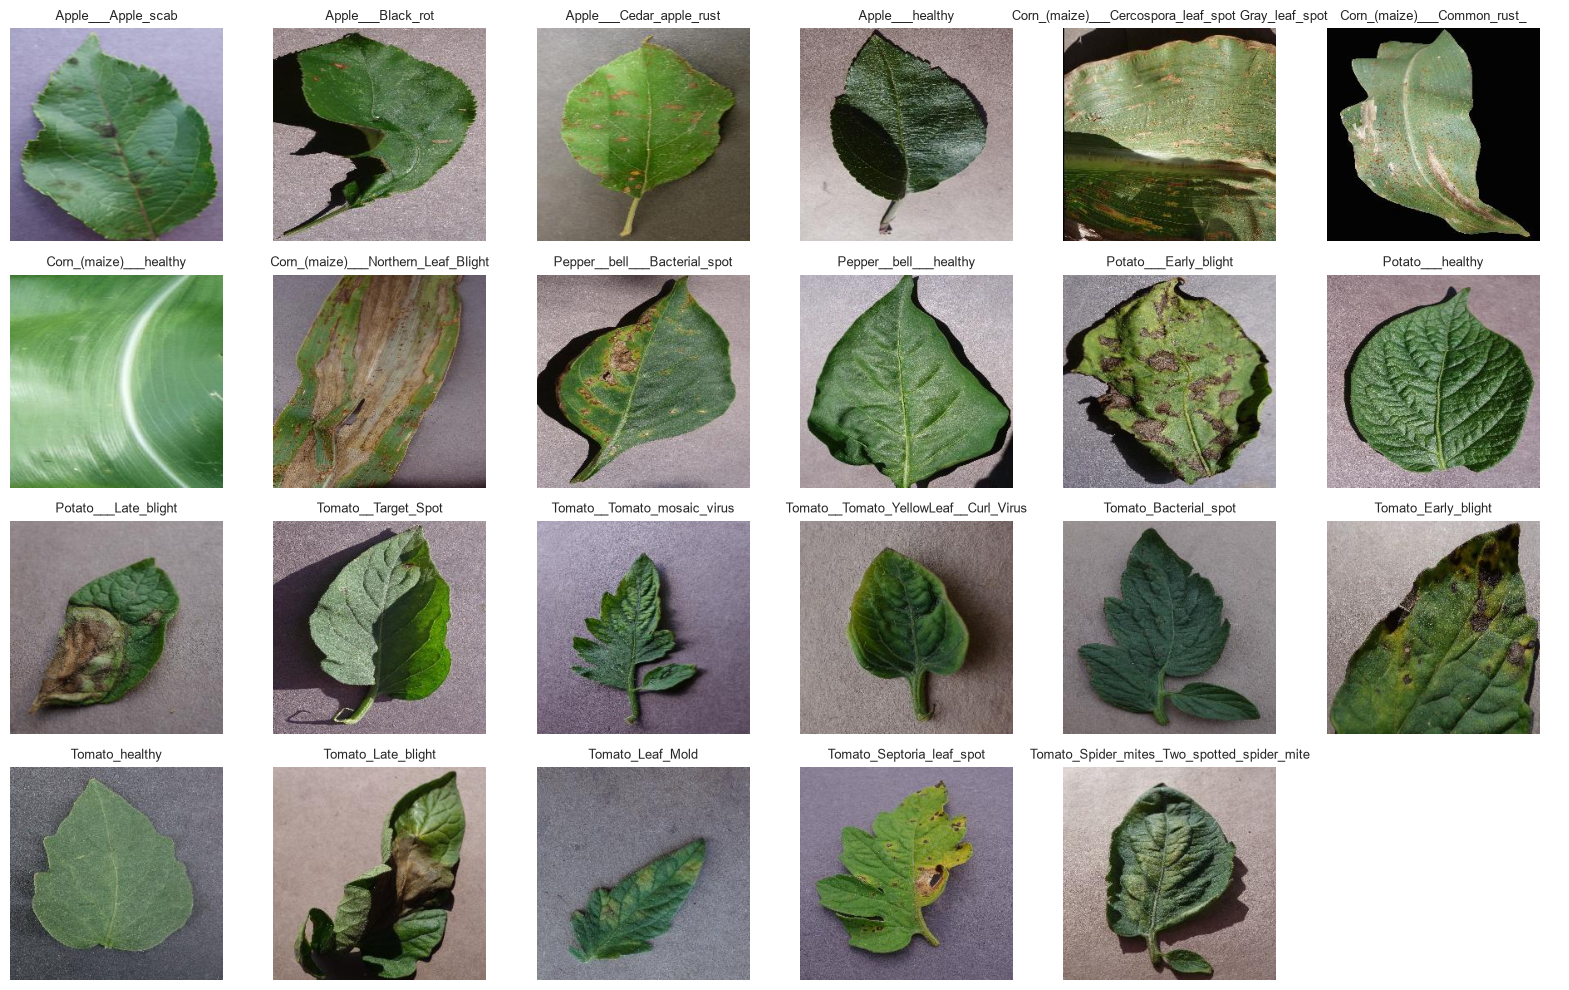

In [15]:
fig, axes = plt.subplots(4, 6, figsize=(16, 10))
axes = axes.flatten()

idx = 0
for class_name, img_path in sample_images:
    if idx >= len(axes):
        break
    img = Image.open(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(class_name, fontsize=9)
    axes[idx].axis('off')
    idx += 1

for j in range(idx, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Pixel Value Statistics

In [16]:
pixel_stats = []
for class_name, img_path in sample_images[:5]:
    img_array = np.array(Image.open(img_path))
    pixel_stats.append({
        'Class': class_name,
        'Mean': img_array.mean(),
        'Std': img_array.std(),
        'Min': img_array.min(),
        'Max': img_array.max()
    })

pixel_df = pd.DataFrame(pixel_stats)
print(pixel_df.to_string())

                                                Class        Mean        Std  Min  Max
0                                  Apple___Apple_scab  120.236053  47.402431    0  226
1                                   Apple___Black_rot  110.146540  58.107689    0  255
2                            Apple___Cedar_apple_rust  102.877146  41.679160    0  243
3                                     Apple___healthy  123.635610  63.153295    0  242
4  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot   93.326385  57.702491    0  255


## Summary & Recommendations

In [18]:
print("\n" + "="*60)
print("EDA SUMMARY")
print("="*60)
print(f"Total images: {total_images}")
print(f"Total classes: {num_classes}")
print(f"Class imbalance ratio: {max(class_counts.values()) / min(class_counts.values()):.2f}x")
print(f"Augmented images detected: {'Yes' if augmented_images else 'No'}")
print(f"Train/Val leakage risk: {'HIGH' if overlap_df['Overlap'].sum() > 0 else 'NONE'}")
print(f"Image size consistency: {'Varies' if sizes_df.drop_duplicates().shape[0] > 1 else 'Consistent'}")


EDA SUMMARY
Total images: 35414
Total classes: 23
Class imbalance ratio: 21.11x
Augmented images detected: Yes
Train/Val leakage risk: HIGH
Image size consistency: Consistent
